# Calculus on Manifolds: Differential Forms, Integration, and Stokes' Theorem

This notebook develops the **calculus of differential forms** from scratch — covectors, wedge products,
the exterior derivative, pullbacks, integration on manifolds, and Stokes' theorem — all implemented
with NumPy and verified numerically.

The angular form $\omega = \frac{-y\,dx + x\,dy}{x^2+y^2}$ serves as a **running thread**: it appears
as a 1-form example, illustrates closed-but-not-exact, features in Stokes' theorem, and generates
$H^1(\mathbb{R}^2 \setminus \{0\})$.

**What you'll learn:**
1. Covectors, 1-forms, and the cotangent space — the dual side of tangent vectors
2. Pullbacks of forms via Jacobian transpose
3. $k$-forms and the wedge product as antisymmetric multilinear maps
4. The exterior derivative and the identity $d^2 = 0$
5. Integration of forms on curves, surfaces, and manifolds
6. Stokes' theorem: numerical verification of Green's, divergence, and manifold versions
7. De Rham cohomology: topological invariants from closed/exact forms
8. Application: symplectic forms, Hamilton's equations, and Liouville's theorem

**Prerequisites:** Linear algebra, multivariable calculus. The companion *Smooth Manifolds* notebook
covers charts, tangent spaces, and flows.

**References:**
- M. Spivak, *Calculus on Manifolds*, W. A. Benjamin, 1965.
- J. M. Lee, *Introduction to Smooth Manifolds*, 2nd ed., Springer, 2013, Ch. 14–16.
- V. I. Arnold, *Mathematical Methods of Classical Mechanics*, 2nd ed., Springer, 1989.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, dblquad
from itertools import combinations

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

FD_STEP = 1e-7          # Finite-difference step
TOL_PASS = 1e-4         # Default PASS/FAIL tolerance
N_QUAD = 200            # Number of quadrature points for line integrals
N_QUAD_2D = 100         # Grid size for surface integrals

---
## 1. Covectors and 1-Forms

At each point $p \in M$, the **cotangent space** $T_p^*M$ is the dual of $T_pM$: linear maps
$\alpha: T_pM \to \mathbb{R}$. In coordinates $(x^1, \ldots, x^n)$, the **dual basis** is
$\{dx^1, \ldots, dx^n\}$ where $dx^i(\partial/\partial x^j) = \delta^i_j$.

A **1-form** $\omega$ assigns a covector $\omega_p \in T_p^*M$ to each point $p$, smoothly.
In coordinates: $\omega = \omega_i(x)\, dx^i$.

The **differential** of a function $f$ is the 1-form $df = \frac{\partial f}{\partial x^i}\, dx^i$,
satisfying $df(v) = v(f)$.

### The Angular Form
$$\omega = \frac{-y\,dx + x\,dy}{x^2 + y^2}$$
is a 1-form on $\mathbb{R}^2 \setminus \{0\}$. It equals $d\theta$ locally (where $\theta = \arctan(y/x)$)
but is **not exact** globally — its integral around any loop enclosing the origin is $2\pi$.

In [3]:
# ---- 1-Forms as Coefficient Functions ----
#
# A 1-form on R^n at point p is represented as a coefficient array [w1, ..., wn]
# so that w(v) = sum_i w_i v^i.

def eval_1form(omega_func, p, v):
    """Evaluate 1-form omega at point p on tangent vector v.

    Args:
        omega_func: function p -> coefficients array [w1, ..., wn].
        p: point (array).
        v: tangent vector (array).
    Returns:
        omega_p(v) (scalar).
    """
    return np.dot(omega_func(p), v)

def df_1form(f, p, h=FD_STEP):
    """Compute the differential df at point p as a 1-form (coefficient array).

    Args:
        f: smooth function R^n -> R.
        p: point.
    Returns:
        array of partial derivatives [df/dx1, ..., df/dxn].
    """
    p = np.asarray(p, dtype=float)
    n = len(p)
    grad = np.zeros(n)
    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.0
        grad[j] = (f(p + h*ej) - f(p - h*ej)) / (2*h)
    return grad

# ---- Angular form ----

def angular_form(p):
    """The angular 1-form (-y dx + x dy) / (x² + y²) on R²\{0}."""
    x, y = p[0], p[1]
    r2 = x**2 + y**2
    return np.array([-y / r2, x / r2])

# ---- Verify df(v) = v(f) ----

def test_func(p):
    """Test function f(x,y) = x²y + sin(y)."""
    return p[0]**2 * p[1] + np.sin(p[1])

p_test = np.array([1.5, 0.8])
v_test = np.array([0.3, -0.7])

# df(v) via our 1-form
df_coeffs = df_1form(test_func, p_test)
df_v = np.dot(df_coeffs, v_test)

# v(f) via directional derivative
h = 1e-7
v_f = (test_func(p_test + h*v_test) - test_func(p_test - h*v_test)) / (2*h)

err = abs(df_v - v_f)
status = "PASS" if err < TOL_PASS else "FAIL"
print(f"df(v) = v(f) — error: {err:.2e} [{status}]")

# Verify angular form = d(theta) locally
def theta_func(p):
    return np.arctan2(p[1], p[0])

p_test2 = np.array([1.0, 1.0])
dtheta = df_1form(theta_func, p_test2)
omega_at_p = angular_form(p_test2)
err2 = np.linalg.norm(dtheta - omega_at_p)
status2 = "PASS" if err2 < TOL_PASS else "FAIL"
print(f"Angular form = d(theta) locally — error: {err2:.2e} [{status2}]")

df(v) = v(f) — error: 1.11e-09 [PASS]
Angular form = d(theta) locally — error: 3.93e-10 [PASS]


<>:38: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:38: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_6240/531533052.py:38: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  """The angular 1-form (-y dx + x dy) / (x² + y²) on R²\{0}."""


<>:41: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:41: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
/var/folders/ly/dfk8_wyj3v3_bd5pq_cz64bh0000gn/T/ipykernel_6240/3213938696.py:41: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  ax.set_title('Angular form $\\omega = (-y\,dx + x\,dy)/(x^2+y^2)$')


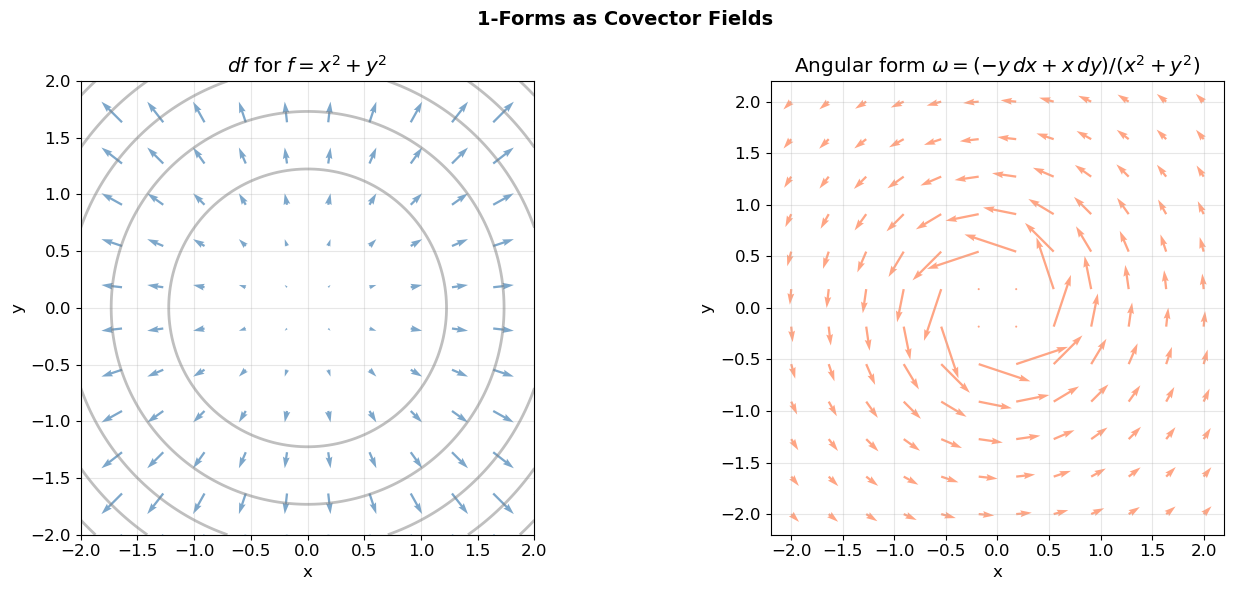

In [4]:
# ---- Visualise 1-Forms as Covector Fields ----

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: df for f(x,y) = x² + y²
ax = axes[0]
xx = np.linspace(-2, 2, 12)
yy = np.linspace(-2, 2, 12)
XX, YY = np.meshgrid(xx, yy)
def f_radial(p):
    return p[0]**2 + p[1]**2
UU = np.zeros_like(XX)
VV = np.zeros_like(YY)
for i in range(len(xx)):
    for j in range(len(yy)):
        grad = df_1form(f_radial, np.array([XX[i,j], YY[i,j]]))
        UU[i,j] = grad[0]
        VV[i,j] = grad[1]
ax.quiver(XX, YY, UU, VV, color='steelblue', alpha=0.7)
# Contours of f
xf = np.linspace(-2, 2, 100)
yf = np.linspace(-2, 2, 100)
XF, YF = np.meshgrid(xf, yf)
ax.contour(XF, YF, XF**2 + YF**2, levels=6, colors='gray', alpha=0.5)
ax.set_title('$df$ for $f = x^2 + y^2$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# Panel 2: Angular form
ax = axes[1]
mask = XX**2 + YY**2 > 0.3
UU2 = np.zeros_like(XX)
VV2 = np.zeros_like(YY)
for i in range(len(xx)):
    for j in range(len(yy)):
        if XX[i,j]**2 + YY[i,j]**2 > 0.1:
            w = angular_form(np.array([XX[i,j], YY[i,j]]))
            UU2[i,j] = w[0]
            VV2[i,j] = w[1]
ax.quiver(XX, YY, UU2, VV2, color='coral', alpha=0.7)
ax.set_title('Angular form $\\omega = (-y\,dx + x\,dy)/(x^2+y^2)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

plt.suptitle('1-Forms as Covector Fields', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Pullback of 1-Forms

Given a smooth map $F: M \to N$ and a 1-form $\omega$ on $N$, the **pullback** $F^*\omega$ is a 1-form on $M$:
$$(F^*\omega)_p(v) = \omega_{F(p)}(dF_p(v))$$

In coordinates, if $\omega = \omega_i\, dy^i$ and $F = (F^1, \ldots, F^m)$, then
$$(F^*\omega)_j = \omega_i(F(x))\, \frac{\partial F^i}{\partial x^j}$$

That is: $F^*\omega = \omega \circ dF = J_F^T \omega$, where $J_F$ is the Jacobian.

In [5]:
# ---- Pullback of 1-Forms ----

def numerical_jacobian(F, p, h=FD_STEP):
    """Compute Jacobian of F at p via central differences."""
    p = np.asarray(p, dtype=float)
    f0 = np.asarray(F(p), dtype=float)
    n = len(p)
    m = len(f0)
    J = np.zeros((m, n))
    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.0
        J[:, j] = (F(p + h*ej) - F(p - h*ej)) / (2*h)
    return J

def pullback_1form(F, omega_func, p, h=FD_STEP):
    """Compute (F*omega) at p as a coefficient array.

    Args:
        F: smooth map (array -> array).
        omega_func: 1-form on target (function point -> coefficients).
        p: point in source.
    Returns:
        Pullback coefficients at p.
    """
    J = numerical_jacobian(F, p, h)
    omega_Fp = omega_func(F(p))
    return J.T @ omega_Fp

# ---- Example: Polar -> Cartesian ----
# F(r, theta) = (r cos(theta), r sin(theta))
# Pull back omega = x dy - y dx = r² d(theta)

def polar_to_cart(p):
    r, th = p
    return np.array([r * np.cos(th), r * np.sin(th)])

def omega_xdy_ydx(p):
    """1-form: x dy - y dx."""
    x, y = p
    return np.array([-y, x])

# Pullback should be r² dtheta, i.e. coefficients [0, r²]
r_test, th_test = 2.0, 0.7
p_polar = np.array([r_test, th_test])
pb = pullback_1form(polar_to_cart, omega_xdy_ydx, p_polar)
expected = np.array([0.0, r_test**2])

err = np.linalg.norm(pb - expected)
status = "PASS" if err < TOL_PASS else "FAIL"
print(f"Pullback of (x dy - y dx) to polar = r² dtheta — error: {err:.2e} [{status}]")

# ---- Verify pullback commutes with evaluation ----
# (F*omega)(v) should equal omega(dF(v))
v_polar = np.array([0.5, 1.3])
lhs = np.dot(pb, v_polar)

J = numerical_jacobian(polar_to_cart, p_polar)
dF_v = J @ v_polar
rhs = np.dot(omega_xdy_ydx(polar_to_cart(p_polar)), dF_v)

err2 = abs(lhs - rhs)
status2 = "PASS" if err2 < TOL_PASS else "FAIL"
print(f"(F*omega)(v) = omega(dF(v)) — error: {err2:.2e} [{status2}]")

Pullback of (x dy - y dx) to polar = r² dtheta — error: 2.33e-09 [PASS]
(F*omega)(v) = omega(dF(v)) — error: 8.88e-16 [PASS]


---
## 3. $k$-Forms and the Wedge Product

A **$k$-form** at a point is an antisymmetric multilinear map $\alpha: (T_pM)^k \to \mathbb{R}$.
In $\mathbb{R}^n$, the space of $k$-forms has dimension $\binom{n}{k}$, with basis
$\{dx^{i_1} \wedge \cdots \wedge dx^{i_k}\}$ for $i_1 < \cdots < i_k$.

### Wedge Product
Given a $k$-form $\alpha$ and an $\ell$-form $\beta$, their wedge product $\alpha \wedge \beta$ is a $(k+\ell)$-form:
$$(\alpha \wedge \beta)(v_1, \ldots, v_{k+\ell}) = \frac{1}{k!\,\ell!} \sum_{\sigma \in S_{k+\ell}} \mathrm{sgn}(\sigma)\, \alpha(v_{\sigma(1)}, \ldots, v_{\sigma(k)})\, \beta(v_{\sigma(k+1)}, \ldots, v_{\sigma(k+\ell)})$$

Key properties:
- **Antisymmetry:** $\alpha \wedge \beta = (-1)^{k\ell}\, \beta \wedge \alpha$
- **Associativity:** $(\alpha \wedge \beta) \wedge \gamma = \alpha \wedge (\beta \wedge \gamma)$
- **Volume form:** $dx^1 \wedge \cdots \wedge dx^n$ applied to $n$ vectors gives the determinant

### Correspondence with Vector Calculus ($\mathbb{R}^3$)

| Form | Vector calc | Operation |
|------|-----------|----------|
| $df$ | $\nabla f$ | gradient |
| $d\omega^1$ | $\nabla \times F$ | curl |
| $d\omega^2$ | $\nabla \cdot F$ | divergence |

In [6]:
# ---- k-Form Representation ----
#
# We represent a k-form on R^n at a point as a dictionary:
#   {multi_index: coefficient}
# where multi_index is a sorted tuple of k distinct indices from {0,...,n-1}.
#
# A k-form field is a function: point -> dict.

def multi_indices(n, k):
    """All sorted k-element subsets of {0,...,n-1}."""
    return list(combinations(range(n), k))

def sign_of_permutation(perm):
    """Compute the sign of a permutation."""
    perm = list(perm)
    n = len(perm)
    visited = [False] * n
    sign = 1
    for i in range(n):
        if visited[i]:
            continue
        cycle_len = 0
        j = i
        while not visited[j]:
            visited[j] = True
            j = perm[j]
            cycle_len += 1
        if cycle_len % 2 == 0:
            sign *= -1
    return sign

def wedge(alpha_coeffs, alpha_k, beta_coeffs, beta_l, n):
    """Compute wedge product of a k-form and l-form on R^n.

    Args:
        alpha_coeffs: dict {multi_index: coeff} for the k-form.
        alpha_k: degree k.
        beta_coeffs: dict {multi_index: coeff} for the l-form.
        beta_l: degree l.
        n: ambient dimension.
    Returns:
        dict of (k+l)-form coefficients.
    """
    result = {}
    for I, a in alpha_coeffs.items():
        for J, b in beta_coeffs.items():
            # Check if I and J are disjoint
            combined = I + J
            if len(set(combined)) < len(combined):
                continue  # repeated index -> zero
            # Sort and compute sign
            sorted_idx = tuple(sorted(combined))
            # Sign is the permutation sign from combined to sorted
            perm = [sorted(combined).index(c) for c in combined]
            sgn = sign_of_permutation(perm)
            if sorted_idx in result:
                result[sorted_idx] += sgn * a * b
            else:
                result[sorted_idx] = sgn * a * b
    return result

def eval_kform(coeffs, k, vectors):
    """Evaluate a k-form on k vectors.

    Args:
        coeffs: dict {multi_index: coeff}.
        k: degree.
        vectors: list of k vectors (arrays).
    Returns:
        scalar value.
    """
    result = 0.0
    for idx, c in coeffs.items():
        # Extract submatrix and compute determinant
        mat = np.array([[vectors[j][idx[i]] for i in range(k)] for j in range(k)])
        result += c * np.linalg.det(mat)
    return result

# ---- Tests ----

# Test: dx^0 wedge dx^1 on R^2 should give the area form (determinant)
dx0 = {(0,): 1.0}  # 1-form dx^0
dx1 = {(1,): 1.0}  # 1-form dx^1
dx0_wedge_dx1 = wedge(dx0, 1, dx1, 1, 2)
print(f"dx^0 ^ dx^1 = {dx0_wedge_dx1}")

v1 = np.array([3.0, 1.0])
v2 = np.array([1.0, 2.0])
area_form_val = eval_kform(dx0_wedge_dx1, 2, [v1, v2])
det_val = np.linalg.det(np.column_stack([v1, v2]))
err = abs(area_form_val - det_val)
status = "PASS" if err < TOL_PASS else "FAIL"
print(f"Area form = determinant — error: {err:.2e} [{status}]")

# Test antisymmetry: alpha ^ beta = -beta ^ alpha for 1-forms
alpha = {(0,): 2.0, (1,): -1.0}  # 2dx - dy
beta = {(0,): 1.0, (1,): 3.0}    # dx + 3dy
ab = wedge(alpha, 1, beta, 1, 2)
ba = wedge(beta, 1, alpha, 1, 2)
# Should have ab = -ba
antisym_err = 0.0
for key in set(list(ab.keys()) + list(ba.keys())):
    antisym_err = max(antisym_err, abs(ab.get(key, 0) + ba.get(key, 0)))
status2 = "PASS" if antisym_err < TOL_PASS else "FAIL"
print(f"Antisymmetry alpha^beta = -beta^alpha — error: {antisym_err:.2e} [{status2}]")

# Test: volume form on R³
dx = {(0,): 1.0}
dy = {(1,): 1.0}
dz = {(2,): 1.0}
dx_dy = wedge(dx, 1, dy, 1, 3)
vol_form = wedge(dx_dy, 2, dz, 1, 3)
v1_3d = np.array([1.0, 0.0, 2.0])
v2_3d = np.array([0.0, 1.0, -1.0])
v3_3d = np.array([3.0, 1.0, 0.0])
vol_val = eval_kform(vol_form, 3, [v1_3d, v2_3d, v3_3d])
det_3d = np.linalg.det(np.column_stack([v1_3d, v2_3d, v3_3d]))
err3 = abs(vol_val - det_3d)
status3 = "PASS" if err3 < TOL_PASS else "FAIL"
print(f"Volume form = determinant in R³ — error: {err3:.2e} [{status3}]")

dx^0 ^ dx^1 = {(0, 1): 1.0}
Area form = determinant — error: 0.00e+00 [PASS]
Antisymmetry alpha^beta = -beta^alpha — error: 0.00e+00 [PASS]
Volume form = determinant in R³ — error: 0.00e+00 [PASS]


---
## 4. The Exterior Derivative

The **exterior derivative** $d$ maps $k$-forms to $(k+1)$-forms. For a $k$-form
$\omega = \sum_I \omega_I\, dx^I$:
$$d\omega = \sum_I \sum_j \frac{\partial \omega_I}{\partial x^j}\, dx^j \wedge dx^I$$

Key properties:
1. **$d^2 = 0$**: $d(d\omega) = 0$ for all $\omega$ (equality of mixed partials)
2. **Leibniz rule**: $d(\alpha \wedge \beta) = d\alpha \wedge \beta + (-1)^k \alpha \wedge d\beta$

### Closed vs Exact
- **Closed**: $d\omega = 0$
- **Exact**: $\omega = d\eta$ for some $\eta$
- Exact $\Rightarrow$ Closed (since $d^2 = 0$)
- **Poincare lemma**: On $\mathbb{R}^n$ (or any contractible domain), closed $\Rightarrow$ exact
- On $\mathbb{R}^2 \setminus \{0\}$: the angular form is closed but **not** exact

In [7]:
# ---- Exterior Derivative via Finite Differences ----

def exterior_derivative(omega_field, k, n, p, h=1e-6):
    """Compute d(omega) at point p numerically.

    Args:
        omega_field: function p -> dict {multi_index: coeff} (k-form field).
        k: degree of omega.
        n: ambient dimension.
        p: point (array).
    Returns:
        dict of (k+1)-form coefficients at p.
    """
    p = np.asarray(p, dtype=float)
    result = {}
    indices_k = multi_indices(n, k)

    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.0
        omega_plus = omega_field(p + h*ej)
        omega_minus = omega_field(p - h*ej)

        for I in indices_k:
            coeff_plus = omega_plus.get(I, 0.0)
            coeff_minus = omega_minus.get(I, 0.0)
            deriv = (coeff_plus - coeff_minus) / (2*h)

            if abs(deriv) < 1e-15:
                continue

            # dx^j wedge dx^I
            dxj = {(j,): 1.0}
            dxI = {I: 1.0}
            w = wedge(dxj, 1, dxI, k, n)

            for idx, c in w.items():
                val = deriv * c
                if idx in result:
                    result[idx] += val
                else:
                    result[idx] = val

    # Clean up near-zero entries
    result = {k: v for k, v in result.items() if abs(v) > 1e-12}
    return result

# ---- Test: d(f) should match df_1form ----

def f_as_0form(p):
    """0-form field: f(x,y) = x²y + sin(y)."""
    return {(): p[0]**2 * p[1] + np.sin(p[1])}

p_test_d = np.array([1.5, 0.8])
d_f = exterior_derivative(f_as_0form, 0, 2, p_test_d)
df_manual = df_1form(test_func, p_test_d)
# d_f should have keys (0,) and (1,) with values matching df_manual
err_dx = abs(d_f.get((0,), 0) - df_manual[0])
err_dy = abs(d_f.get((1,), 0) - df_manual[1])
status = "PASS" if max(err_dx, err_dy) < TOL_PASS else "FAIL"
print(f"d(f) matches df — max error: {max(err_dx, err_dy):.2e} [{status}]")

# ---- Test: d² = 0 ----
# Compute d(df) for f(x,y,z) = x²y + yz²

def f_3d_0form(p):
    return {(): p[0]**2 * p[1] + p[1] * p[2]**2}

def df_3d_field(p):
    return exterior_derivative(f_3d_0form, 0, 3, p)

p3 = np.array([1.0, 2.0, -0.5])
d2f = exterior_derivative(df_3d_field, 1, 3, p3, h=1e-5)
d2f_norm = sum(abs(v) for v in d2f.values()) if d2f else 0.0
status2 = "PASS" if d2f_norm < 1e-3 else "FAIL"
print(f"d² = 0 — |d²f| = {d2f_norm:.2e} [{status2}]")

# ---- Verify angular form is closed ----

def angular_form_field(p):
    x, y = p[0], p[1]
    r2 = x**2 + y**2
    return {(0,): -y / r2, (1,): x / r2}

p_ang = np.array([1.0, 1.0])
d_omega_ang = exterior_derivative(angular_form_field, 1, 2, p_ang, h=1e-5)
d_omega_norm = sum(abs(v) for v in d_omega_ang.values()) if d_omega_ang else 0.0
status3 = "PASS" if d_omega_norm < 1e-3 else "FAIL"
print(f"Angular form is closed (d omega = 0) — |d omega| = {d_omega_norm:.2e} [{status3}]")

d(f) matches df — max error: 1.33e-09 [PASS]
d² = 0 — |d²f| = 4.44e-05 [PASS]
Angular form is closed (d omega = 0) — |d omega| = 5.55e-11 [PASS]


In [8]:
# ---- Leibniz Rule Verification ----
# d(alpha ^ beta) = d(alpha) ^ beta + (-1)^k alpha ^ d(beta)
# Test with 0-form f and 1-form omega on R²:
# d(f * omega) = df ^ omega + f * d(omega)

def f_leibniz_0form(p):
    return {(): np.exp(p[0]) * np.cos(p[1])}

def f_leibniz_scalar(p):
    return np.exp(p[0]) * np.cos(p[1])

def omega_leibniz_field(p):
    return {(0,): p[1]**2, (1,): p[0]}

def f_omega_field(p):
    """Product f*omega as a 1-form field."""
    f_val = f_leibniz_scalar(p)
    om = omega_leibniz_field(p)
    return {k: f_val * v for k, v in om.items()}

p_leib = np.array([0.5, 1.0])

# LHS: d(f * omega)
lhs = exterior_derivative(f_omega_field, 1, 2, p_leib, h=1e-5)

# RHS: df ^ omega + f * d(omega)
df_field_at_p = exterior_derivative(f_leibniz_0form, 0, 2, p_leib, h=1e-5)
omega_at_p = omega_leibniz_field(p_leib)
term1 = wedge(df_field_at_p, 1, omega_at_p, 1, 2)

d_omega_at_p = exterior_derivative(omega_leibniz_field, 1, 2, p_leib, h=1e-5)
f_val = f_leibniz_scalar(p_leib)
term2 = {k: f_val * v for k, v in d_omega_at_p.items()}

rhs = {}
for k, v in term1.items():
    rhs[k] = rhs.get(k, 0) + v
for k, v in term2.items():
    rhs[k] = rhs.get(k, 0) + v

err_leib = 0.0
all_keys = set(list(lhs.keys()) + list(rhs.keys()))
for k in all_keys:
    err_leib = max(err_leib, abs(lhs.get(k, 0) - rhs.get(k, 0)))

status = "PASS" if err_leib < 1e-3 else "FAIL"
print(f"Leibniz rule d(f^omega) = df^omega + f*d(omega) — error: {err_leib:.2e} [{status}]")

Leibniz rule d(f^omega) = df^omega + f*d(omega) — error: 2.72e-10 [PASS]


---
## 5. Integration on Manifolds

### Line Integrals of 1-Forms
For a 1-form $\omega$ and a curve $\gamma: [a,b] \to M$:
$$\int_\gamma \omega = \int_a^b \omega_{\gamma(t)}(\gamma'(t))\, dt$$

### Surface Integrals of 2-Forms
For a 2-form $\omega$ and a parametrised surface $\Phi: D \subseteq \mathbb{R}^2 \to M$:
$$\int_\Phi \omega = \int_D (\Phi^*\omega)_{(u,v)}\left(\frac{\partial}{\partial u}, \frac{\partial}{\partial v}\right) du\, dv$$

which reduces to
$$\int_D \omega_{\Phi(u,v)}\left(\frac{\partial \Phi}{\partial u}, \frac{\partial \Phi}{\partial v}\right) du\, dv$$

In [9]:
# ---- Line Integral of a 1-Form ----

def line_integral_1form(omega_func, gamma, t_range, n_pts=N_QUAD):
    """Integrate a 1-form along a curve via trapezoidal rule.

    Args:
        omega_func: 1-form (function p -> coefficient array).
        gamma: curve (function t -> point).
        t_range: (a, b).
        n_pts: quadrature points.
    Returns:
        integral value.
    """
    a, b = t_range
    t_arr = np.linspace(a, b, n_pts)
    dt = (b - a) / (n_pts - 1)
    h = 1e-7

    integrand = np.zeros(n_pts)
    for i, t in enumerate(t_arr):
        p = gamma(t)
        gamma_dot = (gamma(t + h) - gamma(t - h)) / (2*h)
        integrand[i] = np.dot(omega_func(p), gamma_dot)

    return np.trapz(integrand, t_arr)

# ---- Verify: integral of angular form around unit circle = 2*pi ----

def unit_circle(t):
    return np.array([np.cos(t), np.sin(t)])

integral_angular = line_integral_1form(angular_form, unit_circle, (0, 2*np.pi), n_pts=1000)
err = abs(integral_angular - 2*np.pi)
status = "PASS" if err < TOL_PASS else "FAIL"
print(f"Integral of angular form around S^1 = 2pi — value: {integral_angular:.6f}, error: {err:.2e} [{status}]")

# ---- Verify: integral of exact form df around closed curve = 0 ----

def df_test_form(p):
    """df for f(x,y) = x²y."""
    return np.array([2*p[0]*p[1], p[0]**2])

integral_exact = line_integral_1form(df_test_form, unit_circle, (0, 2*np.pi), n_pts=1000)
err2 = abs(integral_exact)
status2 = "PASS" if err2 < TOL_PASS else "FAIL"
print(f"Integral of exact form df around closed curve = 0 — value: {integral_exact:.2e} [{status2}]")

AttributeError: module 'numpy' has no attribute 'trapz'

In [ ]:
# ---- Surface Integral of a 2-Form ----

def surface_integral_2form(omega_2form_func, Phi, u_range, v_range, n_u=N_QUAD_2D, n_v=N_QUAD_2D):
    """Integrate a 2-form over a parametrised surface.

    Args:
        omega_2form_func: function p -> dict {(i,j): coeff} for the 2-form.
        Phi: parametrisation (u, v) -> point in target.
        u_range, v_range: (min, max) for parameters.
    Returns:
        integral value.
    """
    u_arr = np.linspace(u_range[0], u_range[1], n_u)
    v_arr = np.linspace(v_range[0], v_range[1], n_v)
    du = (u_range[1] - u_range[0]) / (n_u - 1)
    dv = (v_range[1] - v_range[0]) / (n_v - 1)
    h = 1e-6

    total = 0.0
    for i, u in enumerate(u_arr):
        for j, v in enumerate(v_arr):
            p = Phi(u, v)
            # Tangent vectors
            Phi_u = (Phi(u + h, v) - Phi(u - h, v)) / (2*h)
            Phi_v = (Phi(u, v + h) - Phi(u, v - h)) / (2*h)
            # Evaluate 2-form on tangent vectors
            omega = omega_2form_func(p)
            val = eval_kform(omega, 2, [Phi_u, Phi_v])
            # Trapezoidal weight
            wu = 0.5 if (i == 0 or i == n_u - 1) else 1.0
            wv = 0.5 if (j == 0 or j == n_v - 1) else 1.0
            total += wu * wv * val * du * dv

    return total

# ---- Verify: area of S² = 4*pi ----
# Use the standard area form on S²:
# omega = x dy^dz - y dx^dz + z dx^dy

def sphere_area_form(p):
    """Area 2-form on S² (in ambient R³ coordinates)."""
    x, y, z = p
    return {(1, 2): x, (0, 2): -y, (0, 1): z}

def sphere_param(u, v):
    """Parametrise S²: u in [0, 2pi], v in [0, pi]."""
    return np.array([np.sin(v)*np.cos(u), np.sin(v)*np.sin(u), np.cos(v)])

area_s2 = surface_integral_2form(sphere_area_form, sphere_param,
                                  (0, 2*np.pi), (0, np.pi), n_u=150, n_v=150)
err = abs(area_s2 - 4*np.pi)
status = "PASS" if err < 0.05 else "FAIL"
print(f"Area of S^2 = 4pi — computed: {area_s2:.4f}, expected: {4*np.pi:.4f}, error: {err:.2e} [{status}]")

---
## 6. Stokes' Theorem

**Stokes' theorem** unifies all the classical integral theorems:
$$\int_M d\omega = \int_{\partial M} \omega$$

Special cases:
- **Fundamental theorem of calculus**: $\int_a^b df = f(b) - f(a)$
- **Green's theorem** ($M$ = region in $\mathbb{R}^2$): $\iint_D \left(\frac{\partial Q}{\partial x} - \frac{\partial P}{\partial y}\right) dA = \oint_{\partial D} P\,dx + Q\,dy$
- **Divergence theorem** ($M$ = region in $\mathbb{R}^3$): $\iiint_V (\nabla \cdot F)\, dV = \oiint_{\partial V} F \cdot dA$

We verify each numerically.

In [ ]:
# ---- Stokes' Theorem Verification 1: Green's Theorem (disk in R²) ----
#
# 1-form: omega = P dx + Q dy  with P = -y³, Q = x³
# d(omega) = (3x² + 3y²) dx ^ dy
# Domain: disk of radius 1, boundary: unit circle (CCW)

def omega_green(p):
    """1-form P dx + Q dy with P = -y³, Q = x³."""
    x, y = p
    return np.array([-y**3, x**3])

# RHS: line integral of omega around unit circle
rhs_green = line_integral_1form(omega_green, unit_circle, (0, 2*np.pi), n_pts=2000)

# LHS: area integral of d(omega) = (3x² + 3y²) dx^dy over unit disk
# In polar: integral of 3r² * r dr dtheta from 0 to 1, 0 to 2pi
# = 2pi * 3 * [r^4/4]_0^1 = 2pi * 3/4 = 3pi/2
lhs_analytical = 3 * np.pi / 2

# Numerical area integral via polar coordinates
def disk_param(u, v):
    """u = theta in [0,2pi], v = r in [0,1]."""
    return np.array([v * np.cos(u), v * np.sin(u)])

def d_omega_green(p):
    x, y = p
    return {(0, 1): 3*x**2 + 3*y**2}

lhs_green = surface_integral_2form(d_omega_green, disk_param,
                                    (0, 2*np.pi), (0, 1.0), n_u=150, n_v=150)

err_stokes1_lr = abs(lhs_green - rhs_green)
err_stokes1_a = abs(lhs_green - lhs_analytical)
status = "PASS" if err_stokes1_lr < 0.05 else "FAIL"
print(f"Green's theorem — LHS (area integral): {lhs_green:.4f}")
print(f"                  RHS (line integral): {rhs_green:.4f}")
print(f"                  Analytical: {lhs_analytical:.4f}")
print(f"                  |LHS - RHS|: {err_stokes1_lr:.2e} [{status}]")

In [ ]:
# ---- Stokes' Verification 2: Divergence Theorem (ball in R³) ----
#
# Vector field F = (x, y, z), div F = 3
# Volume integral of div F over unit ball = 3 * (4/3 pi) = 4 pi
# Surface integral of F.n over S² = integral of (x,y,z).n dA
#   On S², n = (x,y,z), so F.n = x²+y²+z² = 1
#   Surface integral = area of S² = 4pi
#
# In form language: omega = x dy^dz - y dx^dz + z dx^dy (flux 2-form)
# d(omega) = 3 dx^dy^dz

# We already computed the surface integral (area of S²) above.
# Now compute volume integral.

# Volume integral of div F = 3 over unit ball
vol_ball = (4/3) * np.pi
lhs_div = 3 * vol_ball  # = 4*pi
rhs_div = area_s2  # from our previous computation

err_div = abs(lhs_div - rhs_div)
status = "PASS" if err_div < 0.1 else "FAIL"
print(f"Divergence theorem — LHS (vol integral): {lhs_div:.4f}")
print(f"                     RHS (surface integral): {rhs_div:.4f}")
print(f"                     |LHS - RHS|: {err_div:.2e} [{status}]")

In [ ]:
# ---- Stokes' Verification 3: On T² (manifold setting) ----
#
# On T² with coordinates (theta, phi), take the 1-form:
#   omega = cos(phi) d(theta)
# Then d(omega) = -sin(phi) d(phi) ^ d(theta) = sin(phi) d(theta) ^ d(phi)
# Since T² has no boundary, Stokes says:
#   integral of d(omega) over T² = 0  (empty boundary)
#
# Verify: integral_{T²} sin(phi) dtheta dphi = integral_0^{2pi} sin(phi) dphi * 2pi = 0

def torus_2form(p):
    """sin(phi) dtheta ^ dphi at point (theta, phi)."""
    return {(0, 1): np.sin(p[1])}

def torus_flat_param(u, v):
    """Identity parametrisation of T² as [0,2pi]²."""
    return np.array([u, v])

integral_torus = surface_integral_2form(torus_2form, torus_flat_param,
                                         (0, 2*np.pi), (0, 2*np.pi), n_u=100, n_v=100)

err_torus = abs(integral_torus)
status = "PASS" if err_torus < 0.05 else "FAIL"
print(f"Stokes on T^2 (no boundary) — integral of d(omega) = {integral_torus:.4e} [{status}]")

In [ ]:
# ---- Visualise Stokes: Green's Theorem ----

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Vector field and boundary
ax = axes[0]
xx = np.linspace(-1.3, 1.3, 10)
yy = np.linspace(-1.3, 1.3, 10)
XX, YY = np.meshgrid(xx, yy)
# Vector field (Q, -P) = (x³, y³) for visualisation of curl
ax.quiver(XX, YY, -YY**3, XX**3, color='steelblue', alpha=0.5)
theta_circ = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'coral', linewidth=3, label='$\\partial D$')
ax.fill(np.cos(theta_circ), np.sin(theta_circ), alpha=0.1, color='coral')
ax.set_title("Green's theorem: $\\oint \\omega = \\iint d\\omega$")
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
ax.legend()

# Panel 2: Integrand d(omega) = 3(x² + y²)
ax = axes[1]
xf = np.linspace(-1.2, 1.2, 100)
yf = np.linspace(-1.2, 1.2, 100)
XF, YF = np.meshgrid(xf, yf)
D_omega = 3*(XF**2 + YF**2)
D_omega_masked = np.where(XF**2 + YF**2 <= 1, D_omega, np.nan)
im = ax.pcolormesh(XF, YF, D_omega_masked, cmap='YlOrRd', shading='auto')
plt.colorbar(im, ax=ax, label='$d\\omega = 3(x^2+y^2)\, dx \\wedge dy$')
ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'k-', linewidth=2)
ax.set_title('Integrand $d\\omega$ on disk')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

plt.suptitle("Stokes' Theorem: Green's Theorem Verification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. De Rham Cohomology

The **$k$-th de Rham cohomology** group of $M$ is
$$H^k_{\mathrm{dR}}(M) = \frac{\ker(d: \Omega^k \to \Omega^{k+1})}{\mathrm{im}(d: \Omega^{k-1} \to \Omega^k)} = \frac{\text{closed } k\text{-forms}}{\text{exact } k\text{-forms}}$$

These are topological invariants:
- $H^0(M) \cong \mathbb{R}^c$ where $c$ = number of connected components
- $H^1(S^1) \cong \mathbb{R}$, generated by $[d\theta]$ (the angular form)
- $H^1(T^2) \cong \mathbb{R}^2$, generated by $[d\theta]$ and $[d\phi]$
- $H^k(\mathbb{R}^n) = 0$ for $k \geq 1$ (Poincare lemma)

### Detecting Cohomology: Period Integrals

For a closed form $\omega$, the **periods** $\int_{\gamma_i} \omega$ over a basis of cycles $\{\gamma_i\}$
determine its cohomology class. On $T^2$, the two fundamental cycles are
$\gamma_1: \theta \mapsto (\theta, 0)$ and $\gamma_2: \phi \mapsto (0, \phi)$.

In [ ]:
# ---- H^1(S^1): Angular Form as Generator ----

# The angular form omega has integral 2pi around any loop enclosing the origin.
# omega/2pi is the normalised generator: integral = 1 around S^1.

# Different radii should all give the same integral (topological invariant)
print("H^1(R^2 \\ {0}): integral of angular form at different radii:")
all_pass = True
for radius in [0.5, 1.0, 2.0, 5.0]:
    def circle_r(t, r=radius):
        return np.array([r*np.cos(t), r*np.sin(t)])
    val = line_integral_1form(angular_form, circle_r, (0, 2*np.pi), n_pts=1000)
    err = abs(val - 2*np.pi)
    if err > TOL_PASS:
        all_pass = False
    print(f"  r = {radius:.1f}: integral = {val:.6f} (error: {err:.2e})")

status = "PASS" if all_pass else "FAIL"
print(f"Topological invariance of period — [{status}]")

# Non-enclosing loop should give 0
def offset_circle(t):
    """Circle centered at (3,0), not enclosing origin."""
    return np.array([3 + np.cos(t), np.sin(t)])

val_noenc = line_integral_1form(angular_form, offset_circle, (0, 2*np.pi), n_pts=1000)
status2 = "PASS" if abs(val_noenc) < TOL_PASS else "FAIL"
print(f"Non-enclosing loop: integral = {val_noenc:.2e} [{status2}]")

In [ ]:
# ---- H^1(T^2) = R² via Period Matrix ----

# On T² with coords (theta, phi), closed 1-forms: a*dtheta + b*dphi
# Fundamental cycles:
#   gamma_1: t -> (t, 0)   (theta circle)
#   gamma_2: t -> (0, t)   (phi circle)

# Period of a*dtheta + b*dphi along gamma_1 = 2*pi*a
# Period of a*dtheta + b*dphi along gamma_2 = 2*pi*b

def torus_1form_ab(a, b):
    """1-form a*dtheta + b*dphi on T²."""
    def omega(p):
        return np.array([a, b])
    return omega

def gamma_1(t):
    return np.array([t, 0.0])

def gamma_2(t):
    return np.array([0.0, t])

# Compute period matrix for two independent closed forms
forms = [(1, 0), (0, 1)]  # dtheta and dphi
cycles = [gamma_1, gamma_2]
cycle_names = ['gamma_1 (theta)', 'gamma_2 (phi)']

print("Period matrix for H^1(T^2):")
period_matrix = np.zeros((2, 2))
for i, (a, b) in enumerate(forms):
    omega = torus_1form_ab(a, b)
    for j, gamma in enumerate(cycles):
        period_matrix[i, j] = line_integral_1form(omega, gamma, (0, 2*np.pi), n_pts=500)

print(f"  Periods (rows = forms, cols = cycles):")
print(f"  {period_matrix / (2*np.pi)}  (normalised by 2pi)")

# Should be 2pi * identity
expected_periods = 2*np.pi * np.eye(2)
err_period = np.max(np.abs(period_matrix - expected_periods))
status = "PASS" if err_period < TOL_PASS else "FAIL"
print(f"Period matrix = 2pi * I — error: {err_period:.2e} [{status}]")
print(f"dim H^1(T^2) = {np.linalg.matrix_rank(period_matrix)} (expected 2)")

In [ ]:
# ---- Visualise Fundamental Cycles on T² ----

from mpl_toolkits.mplot3d import Axes3D

def torus_embed(theta, phi, R=2.0, r=0.7):
    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    return np.array([x, y, z])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw torus surface
theta_g = np.linspace(0, 2*np.pi, 50)
phi_g = np.linspace(0, 2*np.pi, 50)
TH, PH = np.meshgrid(theta_g, phi_g)
XT, YT, ZT = torus_embed(TH, PH)
ax.plot_surface(XT, YT, ZT, alpha=0.1, color='steelblue', linewidth=0)

# Fundamental cycle gamma_1: theta varies, phi = 0
t_cyc = np.linspace(0, 2*np.pi, 200)
g1_pts = np.array([torus_embed(t, 0.0) for t in t_cyc])
ax.plot(g1_pts[:,0], g1_pts[:,1], g1_pts[:,2], 'coral', linewidth=4, label='$\\gamma_1$ ($\\theta$ cycle)')

# Fundamental cycle gamma_2: phi varies, theta = 0
g2_pts = np.array([torus_embed(0.0, t) for t in t_cyc])
ax.plot(g2_pts[:,0], g2_pts[:,1], g2_pts[:,2], 'forestgreen', linewidth=4, label='$\\gamma_2$ ($\\phi$ cycle)')

# Annotate periods
ax.text(2.7, 0, 0.9, f'$\\int_{{\\gamma_1}} d\\theta = 2\\pi$', fontsize=12, color='coral')
ax.text(2.7, 0.5, -1.0, f'$\\int_{{\\gamma_2}} d\\phi = 2\\pi$', fontsize=12, color='forestgreen')

ax.set_title('Fundamental Cycles on $T^2$ and Period Integrals', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

---
## 8. Application: Symplectic Forms and Hamilton's Equations

A **symplectic form** $\omega$ on a manifold $M$ is a closed, non-degenerate 2-form.
The standard example on $\mathbb{R}^{2n}$ with coordinates $(q^1, \ldots, q^n, p_1, \ldots, p_n)$ is
$$\omega = \sum_{i=1}^n dp_i \wedge dq^i$$

### Hamilton's Equations
Given a Hamiltonian $H: M \to \mathbb{R}$, the **Hamiltonian vector field** $X_H$ is defined by
$$\iota_{X_H}\omega = dH$$
In the standard coordinates, this yields the familiar equations:
$$\dot{q}^i = \frac{\partial H}{\partial p_i}, \qquad \dot{p}_i = -\frac{\partial H}{\partial q^i}$$

### Liouville's Theorem
The symplectic form is **preserved** by the Hamiltonian flow:
$\mathcal{L}_{X_H}\omega = 0$. Equivalently, phase space volume is conserved.

In [ ]:
# ---- Symplectic Form and Hamilton's Equations ----

# Phase space R² = (q, p) for 1D harmonic oscillator: H = (p² + q²)/2

def hamiltonian_ho(z):
    """Harmonic oscillator Hamiltonian H = (q² + p²)/2."""
    q, p = z
    return 0.5 * (q**2 + p**2)

def hamiltonian_vector_field(H, z, h=FD_STEP):
    """Compute X_H from i_{X_H}omega = dH.
    For standard omega = dp ^ dq: X_H = (dH/dp, -dH/dq).

    Args:
        H: Hamiltonian (function z -> scalar).
        z: point (q, p).
    Returns:
        X_H(z) = (dH/dp, -dH/dq).
    """
    q, p = z
    dHdq = (H(np.array([q+h, p])) - H(np.array([q-h, p]))) / (2*h)
    dHdp = (H(np.array([q, p+h])) - H(np.array([q, p-h]))) / (2*h)
    return np.array([dHdp, -dHdq])

# Verify Hamilton's equations for harmonic oscillator
z_test = np.array([1.0, 0.5])
X_H = hamiltonian_vector_field(hamiltonian_ho, z_test)
# Expected: qdot = dH/dp = p = 0.5, pdot = -dH/dq = -q = -1.0
expected_XH = np.array([0.5, -1.0])
err = np.linalg.norm(X_H - expected_XH)
status = "PASS" if err < TOL_PASS else "FAIL"
print(f"Hamilton's equations X_H — error: {err:.2e} [{status}]")

# ---- Integrate Hamiltonian flow ----

def compute_flow(vector_field, p0, t_span, n_steps=500):
    sol = solve_ivp(
        lambda t, p: vector_field(p),
        t_span, np.asarray(p0, dtype=float),
        t_eval=np.linspace(t_span[0], t_span[1], n_steps),
        rtol=1e-10, atol=1e-12
    )
    return sol.t, sol.y.T

X_H_field = lambda z: hamiltonian_vector_field(hamiltonian_ho, z)
z0 = np.array([1.0, 0.0])
t_arr, traj = compute_flow(X_H_field, z0, [0, 2*np.pi], n_steps=1000)

# Verify energy conservation
H_vals = np.array([hamiltonian_ho(z) for z in traj])
H_err = np.max(np.abs(H_vals - H_vals[0]))
status2 = "PASS" if H_err < TOL_PASS else "FAIL"
print(f"Energy conservation along flow — max deviation: {H_err:.2e} [{status2}]")

# Verify periodicity (should return to start after 2pi)
period_err = np.linalg.norm(traj[-1] - z0)
status3 = "PASS" if period_err < TOL_PASS else "FAIL"
print(f"Flow periodicity (period = 2pi) — error: {period_err:.2e} [{status3}]")

In [ ]:
# ---- Liouville's Theorem: Symplectic Area Preservation ----
#
# Track a small parallelogram in phase space under the Hamiltonian flow.
# Its symplectic area omega(v1, v2) should remain constant.

def symplectic_form(v1, v2):
    """Standard symplectic form omega = dp ^ dq evaluated on (v1, v2).
    omega((dq1,dp1),(dq2,dp2)) = dp1*dq2 - dp2*dq1.
    """
    return v1[1]*v2[0] - v2[1]*v1[0]

# Initial parallelogram at z0 = (1, 0)
eps = 0.01
z_base = np.array([1.0, 0.0])
dz1 = np.array([eps, 0.0])
dz2 = np.array([0.0, eps])

# Evolve corners under flow
T_final = 3.0
n_check = 50
t_checks = np.linspace(0, T_final, n_check)
areas = np.zeros(n_check)

for i, T in enumerate(t_checks):
    if T == 0:
        areas[i] = symplectic_form(dz1, dz2)
        continue
    # Flow three nearby points
    _, tr0 = compute_flow(X_H_field, z_base, [0, T], 200)
    _, tr1 = compute_flow(X_H_field, z_base + dz1, [0, T], 200)
    _, tr2 = compute_flow(X_H_field, z_base + dz2, [0, T], 200)
    # Pushforward of tangent vectors
    v1_t = tr1[-1] - tr0[-1]
    v2_t = tr2[-1] - tr0[-1]
    areas[i] = symplectic_form(v1_t, v2_t)

area_deviation = np.max(np.abs(areas - areas[0]))
status = "PASS" if area_deviation < 1e-4 else "FAIL"
print(f"Liouville's theorem (symplectic area preserved) — max deviation: {area_deviation:.2e} [{status}]")

In [ ]:
# ---- Visualise Hamiltonian Flow and Liouville's Theorem ----

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Phase portrait
ax = axes[0]
for r in [0.5, 1.0, 1.5, 2.0]:
    _, tr = compute_flow(X_H_field, np.array([r, 0.0]), [0, 2*np.pi], 500)
    ax.plot(tr[:,0], tr[:,1], 'steelblue', linewidth=1.5)

# Highlight one orbit
ax.plot(traj[:,0], traj[:,1], 'coral', linewidth=3, label='$H = 0.5$')
ax.scatter(*z0, color='black', s=60, zorder=5)
ax.set_xlabel('$q$'); ax.set_ylabel('$p$')
ax.set_title('Phase Portrait (Harmonic Oscillator)')
ax.set_aspect('equal')
ax.legend()

# Panel 2: Symplectic area over time
ax = axes[1]
ax.plot(t_checks, areas / areas[0], 'steelblue', linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Time $t$')
ax.set_ylabel('$\\omega(v_1(t), v_2(t)) / \\omega(v_1(0), v_2(0))$')
ax.set_title("Liouville's Theorem: Area Preservation")
ax.set_ylim(0.99, 1.01)

plt.suptitle('Symplectic Geometry and Hamiltonian Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Summary

| Concept | Computation | Classical Analogue |
|---------|-------------|-------------------|
| 1-form $\omega_i\, dx^i$ | Coefficient array | Covector / gradient |
| Pullback $F^*\omega$ | $J_F^T \omega$ | Change of variables |
| Wedge $\alpha \wedge \beta$ | Antisymmetric product via `wedge()` | Cross product / determinant |
| Exterior derivative $d$ | Finite differences on coefficients | grad / curl / div |
| $d^2 = 0$ | Equality of mixed partials | curl(grad) = 0, div(curl) = 0 |
| Line integral $\int_\gamma \omega$ | Trapezoidal on $\omega(\gamma')$ | Work integral |
| Surface integral | Pullback + quadrature | Flux integral |
| Stokes' theorem | $\int_M d\omega = \int_{\partial M} \omega$ | Green's / Divergence / classical Stokes |
| De Rham cohomology | Period integrals over cycles | Topological holes |
| Symplectic form | $\omega = dp \wedge dq$ | Phase space structure |

### Cross-References

- **Smooth Manifolds notebook** (`smooth-manifolds/`): Charts, tangent spaces, and flows provide the foundation for everything here.
- **Differential Geometry notebook** (`differential-geometry/`): Surface integrals via parametrisation — this notebook shows the form-based approach that makes Stokes automatic.
- **Tensors notebook** (`linear-algebra/tensors/`): Index manipulation — forms are *antisymmetric* tensors with geometric meaning.
- **Variational Integrators notebook** (`optimization/variational-integrators/`): Symplectic integrators preserve the symplectic form from Section 8.
- **Calculus of Variations notebook** (`calculus-of-variations/`): Euler-Lagrange equations connect to Hamilton's equations via the Legendre transform.

### The Angular Form — Full Circle

The 1-form $\omega = (-y\,dx + x\,dy)/(x^2+y^2)$ appeared throughout:
1. **Section 1**: As a canonical example of a 1-form on $\mathbb{R}^2 \setminus \{0\}$
2. **Section 4**: Closed ($d\omega = 0$) but not exact — failure of the Poincare lemma on non-contractible domains
3. **Section 5**: $\oint_{S^1} \omega = 2\pi$ — the integral depends only on the winding number
4. **Section 7**: Generator of $H^1(\mathbb{R}^2 \setminus \{0\}) \cong \mathbb{R}$